In [1]:
import pybaseball
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az
from pybaseball import batting_stats

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
C:\Users\Andrew\baseball\.venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [6]:
# loading sample batting data
data = batting_stats(2020,2021)
# isolating model 0 columns
data_m0 = data[['Age','SLG','Barrel%','OBP','HardHit%']]
# normalizing the age value
ages_normal = (data['Age'] - data['Age'].mean()) / data['Age'].std()
data_m0['Age'] = ages_normal
data_m0.head()

,Age,SLG,Barrel%,OBP,HardHit%
31,-0.080183,0.536,0.074,0.375,0.462
5,-1.792138,0.534,0.133,0.465,0.527
15,-1.792138,0.611,0.213,0.364,0.556
3,-0.080183,0.615,0.181,0.429,0.497
50,-0.080183,0.538,0.111,0.355,0.423


In [7]:
# targetting batting avg
y = data['AVG']
y.head()

31    0.328
5     0.313
15    0.282
3     0.309
50    0.266
Name: AVG, dtype: float64

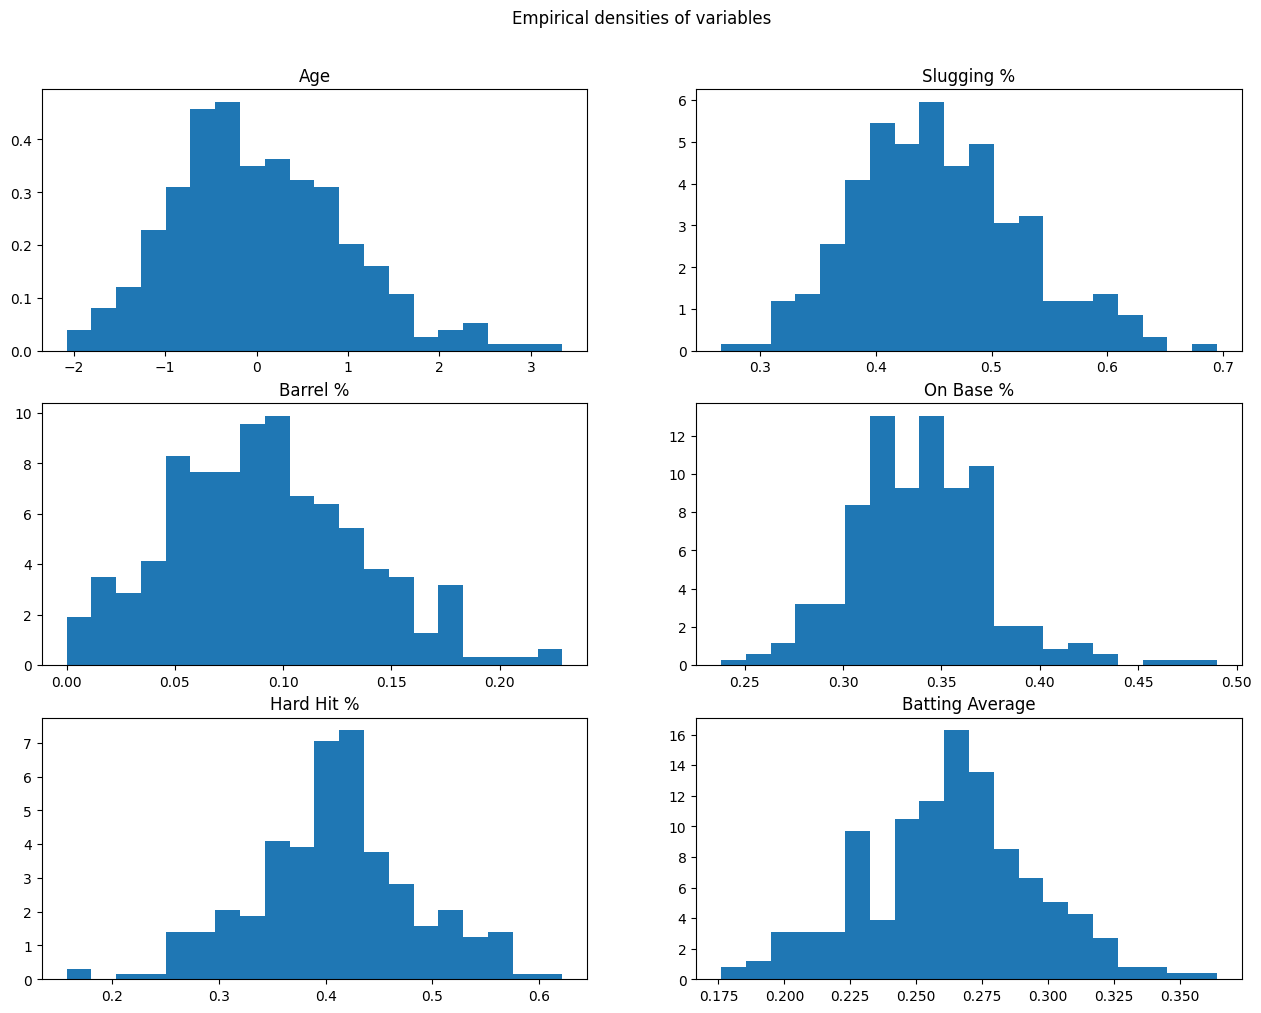

In [8]:
fig, ((ax1,ax2),(ax3,ax4),(ax5,ax6)) = plt.subplots(3,2,figsize=(8,6))
fig.suptitle("Empirical densities of variables")
fig.set_figwidth(15)
fig.set_figheight(10)
ax1.hist(data_m0['Age'],bins=20,density=True)
ax1.set_title('Age')
ax2.hist(data_m0['SLG'],bins=20,density=True)
ax2.set_title('Slugging %')
ax3.hist(data_m0['Barrel%'],bins=20,density=True)
ax3.set_title('Barrel %')
ax4.hist(data_m0['OBP'],bins=20,density=True)
ax4.set_title('On Base %')
ax5.hist(data_m0['HardHit%'],bins=20,density=True)
ax5.set_title('Hard Hit %')
ax6.hist(y,bins=20,density=True)
ax6.set_title('Batting Average')
plt.subplots_adjust(0.1,0.01,top=0.9)
    